In [3]:
# 1. Install required packages (run once in your environment / notebook)

#!pip install gensim pyLDAvis spacy
#!python -m spacy download en_core_web_sm

import re
import numpy as np
import pandas as pd
from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

# spaCy
import spacy

# Visualisation
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import matplotlib.pyplot as plt

%matplotlib inline

# Enable pyLDAvis in Jupyter
pyLDAvis.enable_notebook()

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:
#2 LOADING THE DATSET
#  Load the Amazon Electronics Reviews dataset
df = pd.read_csv("../data/processed/cleaned_reviews_latest.csv")

# Remove rows with missing review text
df = df.dropna(subset=["text"])

# Combine review title and review text (recommended)
df["review"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Convert reviews to a list (same format as the demo)
data = df["review"].tolist()

print(f"Number of documents: {len(data)}")
print("Example document snippet:\n", data[0][:300], "...\n")

print("Number of reviews:", len(df))
print(df.columns.tolist())
print(df["text"].head())

Number of documents: 10518
Example document snippet:
 Smells like gasoline! Going back! First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these.  Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPh ...

Number of reviews: 10518
['title', 'text', 'rating', 'review_length', 'review']
0    First & most offensive: they reek of gasoline ...
1    These didn’t work. Idk if they were damaged in...
2    I love these. They even come with a carry case...
3    I was searching for a sturdy backpack for scho...
4    I've bought these headphones three times becau...
Name: text, dtype: str


In [5]:
# 3. Preprocessing functions
# load spacy's small lanuage model that includes Tokenizer; POS tagger (part-of-speech);
# Lemmatizer; Dependency parser; Named Entity Recognizer (NER) without building dependency tree and
# detecting and labelling named entities (performance)

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def sent_to_words(sentences):
    """Tokenize and clean basic text"""
    for sentence in sentences:
        yield gensim.utils.simple_preprocess(str(sentence), deacc=True)  # lowercase, remove punct

def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(" ".join(doc))
             if word not in gensim.parsing.preprocessing.STOPWORDS]
            for doc in texts]

# specifying the words by their part-of-speech / grammatical category) that should be kept
def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    """Lemmatize with spaCy"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc
                          if token.pos_ in allowed_postags])
    return texts_out

# Apply preprocessing pipeline
data_words = list(sent_to_words(data))
data_words = remove_stopwords(data_words)
data_lemmatized = lemmatization(data_words)


In [6]:
# 4. Create Dictionary & Corpus
id2word = corpora.Dictionary(data_lemmatized)

# Filter extremes (very rare + very common words)
# Keep only tokens that appear in at least 15 documents (absolute number).
# Removes very rare words (hapax legomena, typos, very specific names, noise). These hurt topic
# quality because they don't generalize.
# Keep only tokens that appear in no more than 50% of all documents (fraction of total corpus size).
# Removes extremely common words (stopwords you missed, domain-specific boilerplate like "said",
# "report", "new", "year" in news data). These appear in almost every document, add no
# topic-discriminating power.

print(f"Original vocab size: {len(id2word)}")   # before filter
id2word.filter_extremes(no_below=5, no_above=0.5)
print(f"After filtering: {len(id2word)} tokens remain")
print("Most frequent remaining words:", id2word.most_common(10))

id2word.filter_extremes(no_below=5, no_above=0.5)

corpus = [id2word.doc2bow(text) for text in data_lemmatized]

print(f"Number of unique tokens: {len(id2word)}")
print(f"Number of documents in corpus: {len(corpus)}")



Original vocab size: 11125
After filtering: 3776 tokens remain
Most frequent remaining words: [('work', 5660), ('great', 5019), ('good', 4125), ('use', 3600), ('need', 2572), ('easy', 2379), ('sound', 2286), ('love', 2112), ('time', 1970), ('quality', 1942)]
Number of unique tokens: 3776
Number of documents in corpus: 10518


In [7]:
print("Number of documents:", len(corpus))
print("Vocabulary size:", len(id2word))

Number of documents: 10518
Vocabulary size: 3776


In [8]:
# 6. Train LDA models with different numbers of topics

topic_numbers = [5, 6, 7, 8, 9, 10]

lda_models = {}

for num_topics in topic_numbers:
    
    print(f"\nTraining LDA model with {num_topics} topics...")
    
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=num_topics,
        random_state=42,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
        eta='auto',
        per_word_topics=True
    )
    
    lda_models[num_topics] = lda_model

print("\nAll LDA models trained successfully!")


Training LDA model with 5 topics...

Training LDA model with 6 topics...

Training LDA model with 7 topics...

Training LDA model with 8 topics...

Training LDA model with 9 topics...

Training LDA model with 10 topics...

All LDA models trained successfully!


In [9]:
# 7. Print topics from each LDA model

for num_topics, lda_model in lda_models.items():
    
    print("\n" + "=" * 70)
    print(f"LDA MODEL: {num_topics} TOPICS")
    print("=" * 70)
    
    pprint(lda_model.print_topics(num_words=8))


LDA MODEL: 5 TOPICS
[(0,
  '0.061*"great" + 0.054*"work" + 0.031*"use" + 0.028*"need" + 0.027*"love" + '
  '0.025*"easy" + 0.023*"case" + 0.021*"product"'),
 (1,
  '0.077*"sound" + 0.035*"speaker" + 0.030*"phone" + 0.029*"light" + '
  '0.028*"button" + 0.022*"music" + 0.016*"control" + 0.013*"amazing"'),
 (2,
  '0.055*"good" + 0.028*"quality" + 0.026*"buy" + 0.021*"get" + 0.020*"price" '
  '+ 0.018*"time" + 0.016*"nice" + 0.016*"well"'),
 (3,
  '0.053*"camera" + 0.031*"charge" + 0.029*"cable" + 0.023*"take" + '
  '0.019*"plug" + 0.018*"fast" + 0.017*"video" + 0.014*"fine"'),
 (4,
  '0.033*"device" + 0.026*"tv" + 0.026*"set" + 0.018*"feature" + '
  '0.016*"connect" + 0.015*"picture" + 0.015*"power" + 0.015*"mouse"')]

LDA MODEL: 6 TOPICS
[(0,
  '0.032*"case" + 0.030*"camera" + 0.021*"fit" + 0.021*"look" + 0.019*"nice" + '
  '0.018*"perfect" + 0.017*"laptop" + 0.017*"small"'),
 (1,
  '0.041*"set" + 0.029*"light" + 0.018*"monitor" + 0.017*"read" + 0.016*"home" '
  '+ 0.016*"control" + 0.

In [10]:
# 8. Calculate coherence scores

coherence_scores = {}

for num_topics, lda_model in lda_models.items():
    
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=data_lemmatized,
        dictionary=id2word,
        coherence='c_v'
    )
    
    coherence_score = coherence_model.get_coherence()
    
    coherence_scores[num_topics] = coherence_score
    
    
    print(f"{num_topics} topics: {coherence_score:.4f}")

5 topics: 0.3806
6 topics: 0.3557
7 topics: 0.3182
8 topics: 0.3256
9 topics: 0.2970
10 topics: 0.3270


In [11]:
# Display coherence scores as a table

coherence_df = pd.DataFrame(
    list(coherence_scores.items()),
    columns=["Number of Topics", "Coherence Score"]
)

print(coherence_df)

   Number of Topics  Coherence Score
0                 5         0.380643
1                 6         0.355702
2                 7         0.318225
3                 8         0.325560
4                 9         0.296978
5                10         0.327029


In [12]:
lda_model_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=5,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

# 7. Visualize with pyLDAvis – the interactive masterpiece
vis = gensimvis.prepare(lda_model_final, corpus, id2word,
                        mds='mmds',       # multidimensional scaling
                        R=20,             # number of terms shown per topic
                        sort_topics=False)

# Display in notebook
vis

# mds='mmds'
# Specifies the multidimensional scaling (MDS) method used to lay out the topic circles in 2D space on the left panel.

# The relevance metric (often just called "relevance") in pyLDAvis is a scoring function that ranks and orders the
# words (terms) displayed in the right-hand bar chart for a selected topic. It helps you decide which words best
# characterize or interpret that topic — going beyond just showing the most frequent words in the topic.
# It was introduced in the original LDAvis paper by Sievert & Shirley (2014), and pyLDAvis implements it directly.



d:\ElectronicReviewLDA\venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\ElectronicReviewLDA\venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.248829  0.291472       1        1  32.628258
1     -0.019502 -0.385792       2        1  10.992733
2     -0.382785 -0.094850       3        1  28.624127
3     -0.202946  0.337690       4        1  14.670877
4      0.356404 -0.148520       5        1  13.084005, topic_info=        Term         Freq        Total Category  logprob  loglift
89     great  6243.000000  6243.000000  Default  20.0000  20.0000
20      good  4989.000000  4989.000000  Default  19.0000  19.0000
76      work  5587.000000  5587.000000  Default  18.0000  18.0000
148    sound  2669.000000  2669.000000  Default  17.0000  17.0000
326   camera  2462.000000  2462.000000  Default  16.0000  16.0000
..       ...          ...          ...      ...      ...      ...
212  feature   722.088003   770.818571   Topic5  -4.0455   1.9685
323      set  1083.766333  1375.221577   Topic5  -3.6394   1.7956
622  picture   630.174090  1012.539438   Topic5  -4.1816   1.5596
361   simple   452.776008   789.705541   Topic5  -4.5122   1.4775
130     home   401.240952   522.532640   Topic5  -4.6331   1.7697

[147 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
0         2  0.140156      able
0         4  0.859073      able
579       4  0.997532       add
977       2  0.995405     alexa
898       1  0.004033   amazing
...     ...       ...       ...
67        3  0.998865      well
364       5  0.998007  wireless
76        1  0.998404      work
76        3  0.001432      work
68        3  0.999271      year

[167 rows x 3 columns], R=20, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

In [13]:
# Optional: save as standalone HTML file (very useful for sharing / non-Jupyter)
pyLDAvis.save_html(vis, 'lda_visualization.html')
print("Visualization saved as 'lda_visualization.html'")

Visualization saved as 'lda_visualization.html'


In [14]:
#MEASURE LDA TRAINING TIME
import time

start_time = time.time()

lda_model_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=5,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

end_time = time.time()

training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Training time: 56.32 seconds
Training time: 0.94 minutes


In [15]:
#MEASURE MEMORY USAGE
import psutil
import os

process = psutil.Process(os.getpid())

memory_mb = process.memory_info().rss / (1024 * 1024)

print(f"Current Python process memory: {memory_mb:.2f} MB")

Current Python process memory: 596.48 MB


In [20]:
#MEASURING THE SCALABILITY
import time
import pandas as pd

dataset_sizes = [2000, 5000, 7500, 10518]

scalability_results = []

for size in dataset_sizes:

    print(f"\nRunning LDA with {size} reviews...")

    # Select first 'size' documents
    subset = data_lemmatized[:size]

    # Create dictionary for this dataset
    dictionary = corpora.Dictionary(subset)

    dictionary.filter_extremes(
        no_below=5,
        no_above=0.5
    )

    # Create corpus
    corpus_subset = [
        dictionary.doc2bow(text)
        for text in subset
    ]

    # Measure training time
    start_time = time.time()

    lda_model = gensim.models.LdaModel(
        corpus=corpus_subset,
        id2word=dictionary,
        num_topics=5,
        random_state=42,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
        eta='auto',
        per_word_topics=True
    )

    end_time = time.time()

    training_time = end_time - start_time

    # Calculate coherence
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=subset,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()

    scalability_results.append({
        "Dataset Size": size,
        "Vocabulary Size": len(dictionary),
        "Training Time (seconds)": training_time,
        "Training Time (minutes)": training_time / 60,
        "Coherence": coherence
    })

    print(f"Vocabulary size: {len(dictionary)}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Coherence: {coherence:.4f}")


Running LDA with 2000 reviews...
Vocabulary size: 1331
Training time: 15.29 seconds
Coherence: 0.3430

Running LDA with 5000 reviews...
Vocabulary size: 2663
Training time: 34.54 seconds
Coherence: 0.3447

Running LDA with 7500 reviews...
Vocabulary size: 3496
Training time: 50.64 seconds
Coherence: 0.3469

Running LDA with 10518 reviews...
Vocabulary size: 3776
Training time: 69.70 seconds
Coherence: 0.3806


In [21]:
scalability_df = pd.DataFrame(scalability_results)

print(scalability_df)

   Dataset Size  Vocabulary Size  Training Time (seconds)  \
0          2000             1331                15.294734   
1          5000             2663                34.539134   
2          7500             3496                50.642730   
3         10518             3776                69.701829   

   Training Time (minutes)  Coherence  
0                 0.254912   0.343025  
1                 0.575652   0.344711  
2                 0.844046   0.346885  
3                 1.161697   0.380643  


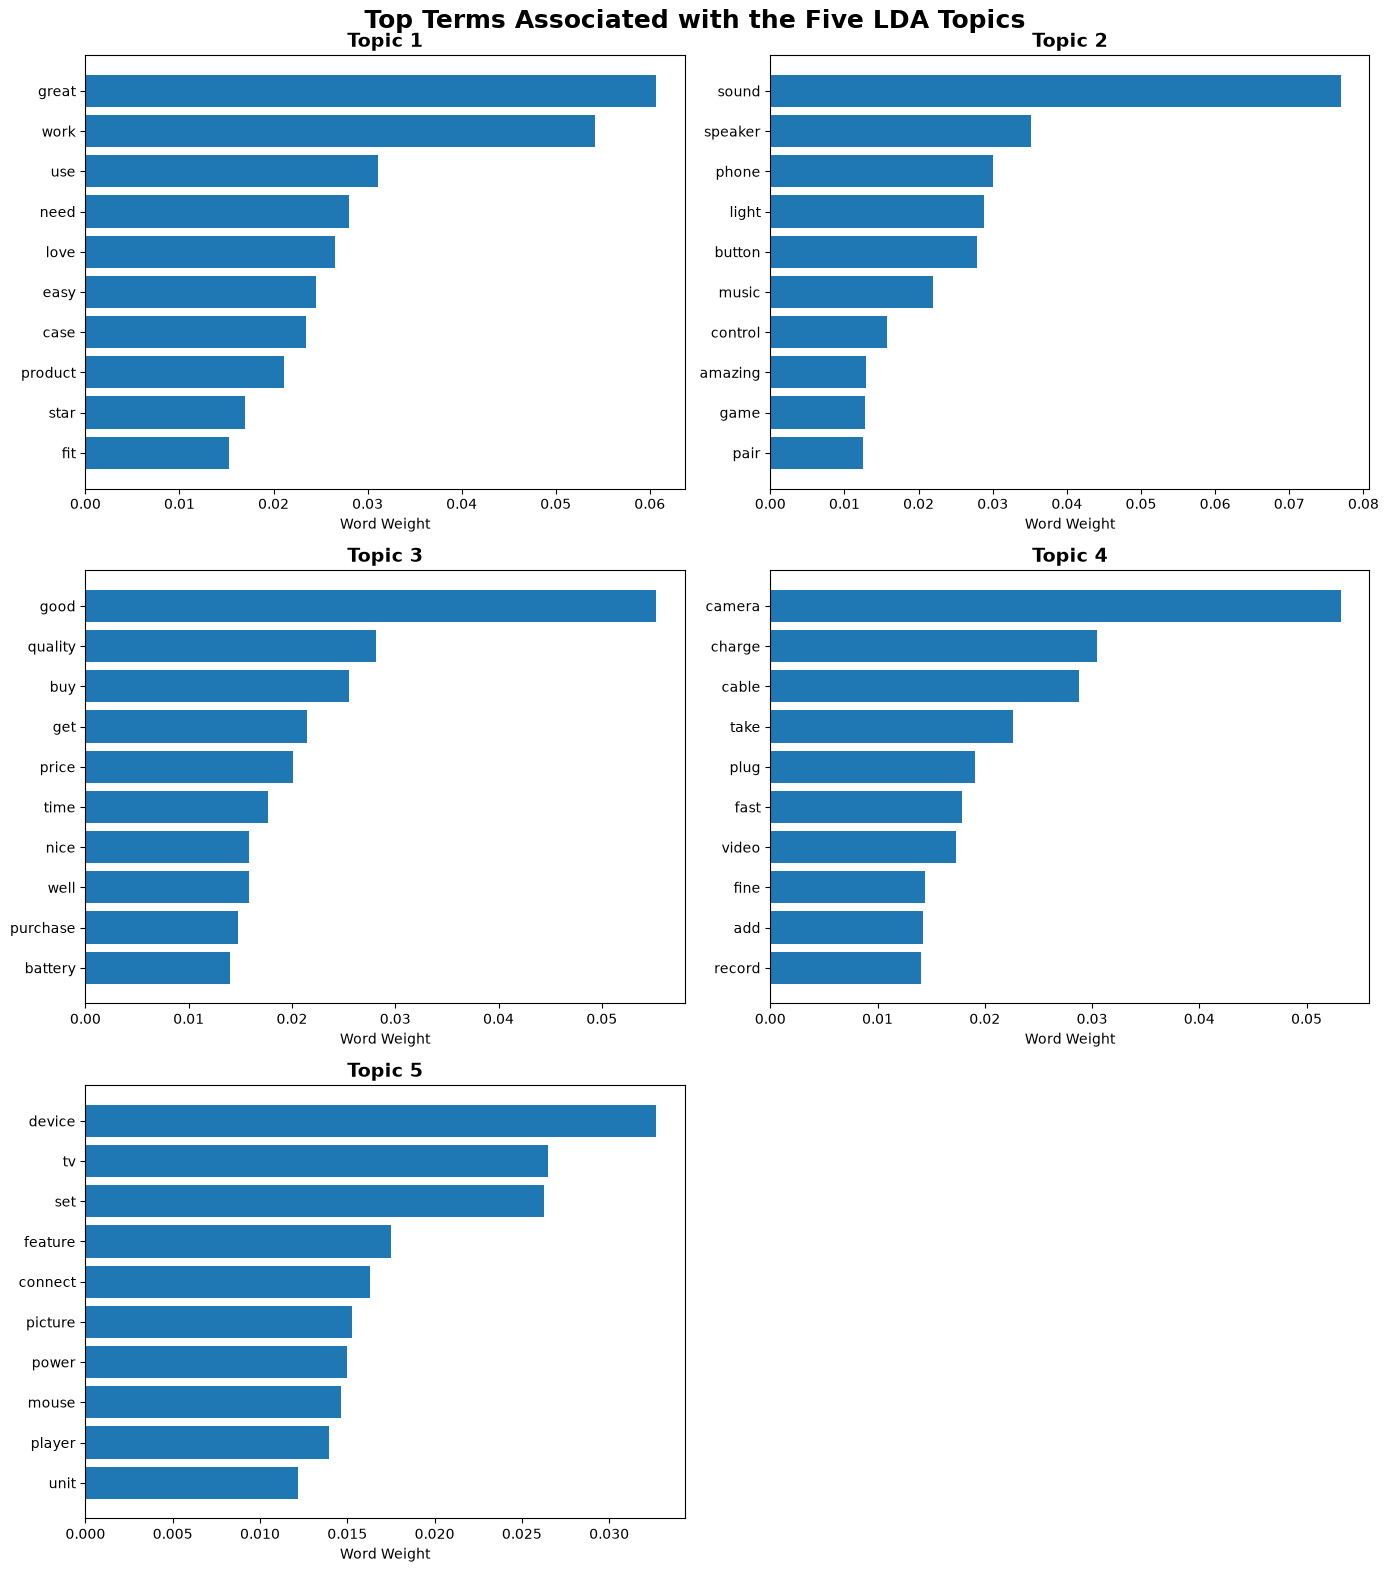

In [18]:
import matplotlib.pyplot as plt

num_topics = 5
num_words = 10

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 16)
)

axes = axes.flatten()

for topic_id in range(num_topics):

    topic_words = lda_model_final.show_topic(
        topic_id,
        topn=num_words
    )

    words = [word for word, weight in topic_words][::-1]
    weights = [weight for word, weight in topic_words][::-1]

    axes[topic_id].barh(words, weights)

    axes[topic_id].set_title(
        f"Topic {topic_id + 1}",
        fontsize=14,
        fontweight="bold"
    )

    axes[topic_id].set_xlabel("Word Weight")
    axes[topic_id].set_ylabel("")

# Remove unused sixth panel
axes[5].axis("off")

fig.suptitle(
    "Top Terms Associated with the Five LDA Topics",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/LDA_Five_Topics_Top_Terms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

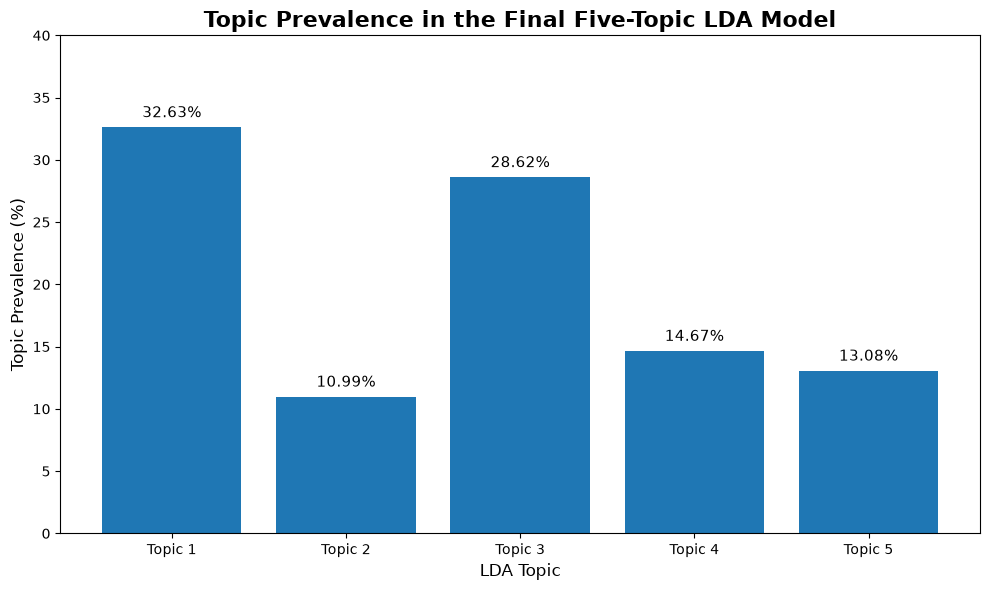

In [19]:
import matplotlib.pyplot as plt

# Topic prevalence from the final 5-topic LDA model
topics = [
    "Topic 1",
    "Topic 2",
    "Topic 3",
    "Topic 4",
    "Topic 5"
]

prevalence = [
    32.63,
    10.99,
    28.62,
    14.67,
    13.08
]

# Create figure
plt.figure(figsize=(10, 6))

bars = plt.bar(topics, prevalence)

# Add percentage labels
for bar, value in zip(bars, prevalence):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title(
    "Topic Prevalence in the Final Five-Topic LDA Model",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("LDA Topic", fontsize=12)
plt.ylabel("Topic Prevalence (%)", fontsize=12)

plt.ylim(0, 40)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "../visualizations/LDA_Topic_Prevalence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()